In [ ]:
!pip install -q tensorflow tensorflow-model-optimization ultralytics

from google.colab import drive
drive.mount('/content/drive')

import os, tempfile, zipfile
import numpy as np
import tensorflow as tf
from tensorflow_model_optimization.python.core.keras.compat import keras
import tensorflow_model_optimization as tfmot

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.8 MB/s eta 0:00:00
Mounted at /content/drive
TensorFlow: 2.20.0
GPU: []


In [ ]:
DATASET_PATH    = '/content/drive/MyDrive/FYP/fyp-preprocessed'
MODEL_SAVE_PATH = '/content/drive/MyDrive/FYP/fyp-model'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

TRAIN_DIR = f'{DATASET_PATH}/train/images'
VAL_DIR   = f'{DATASET_PATH}/val/images'
TEST_DIR  = f'{DATASET_PATH}/test/images'

# FIXED: Changed from 320 to 224 — MobileNetV2 requires 224x224
IMG_SIZE = 224
BATCH    = 32
EPOCHS   = 30
NC       = 21

print(f"Train images: {len(os.listdir(TRAIN_DIR))}")
print(f"Val images  : {len(os.listdir(VAL_DIR))}")
print(f"Test images : {len(os.listdir(TEST_DIR))}")

Train images: 2718
Val images  : 354
Test images : 238


In [ ]:
import cv2
from pathlib import Path

def load_image_and_labels(img_path, label_path, img_size=224):
    img = cv2.imread(str(img_path))
    # FIXED: resize to 224 to match MobileNetV2 expected input
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0

    primary_class = 20
    if label_path.exists():
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if lines:
            primary_class = int(lines[0].split()[0])

    return img.astype(np.float32), primary_class


def build_dataset(img_dir, label_dir, img_size=224):
    img_dir   = Path(img_dir)
    label_dir = Path(label_dir)
    images, labels = [], []

    img_files = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    for img_path in img_files:
        label_path = label_dir / (img_path.stem + '.txt')
        img, label = load_image_and_labels(img_path, label_path, img_size)
        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)


print("Loading datasets...")
train_images, train_labels = build_dataset(
    f'{DATASET_PATH}/train/images',
    f'{DATASET_PATH}/train/labels'
)
val_images, val_labels = build_dataset(
    f'{DATASET_PATH}/val/images',
    f'{DATASET_PATH}/val/labels'
)
test_images, test_labels = build_dataset(
    f'{DATASET_PATH}/test/images',
    f'{DATASET_PATH}/test/labels'
)

print(f"Train: {train_images.shape}")
print(f"Val  : {val_images.shape}")
print(f"Test : {test_images.shape}")

Loading datasets...
Train: (2718, 224, 224, 3)
Val  : (354, 224, 224, 3)
Test : (238, 224, 224, 3)


In [ ]:
def build_tinyml_model(input_shape=(224, 224, 3), num_classes=21):
    # FIXED: input_shape now 224x224 — matches MobileNetV2 pretrained weights
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=0.35
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    model.summary()
    return model


model = build_tinyml_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NC)

2019640/2019640 [==============================] - 1s 1us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_0.35_224 (Func  (None, 7, 7, 1280)        410208    
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 21)                2709      
                                                           

Training baseline model...
Epoch 1/30
170/170 [==============================] - ETA: 0s - loss: 0.9982 - accuracy: 0.6748
Epoch 1: val_loss improved from inf to 1.08098, saving model to /content/drive/MyDrive/FYP/fyp-model/baseline_best.keras
170/170 [==============================] - 63s 368ms/step - loss: 0.9982 - accuracy: 0.6748 - val_loss: 1.0810 - val_accuracy: 0.6469 - lr: 5.0000e-04
Epoch 2/30
170/170 [==============================] - ETA: 0s - loss: 0.8313 - accuracy: 0.7266
Epoch 2: val_loss improved from 1.08098 to 1.02901, saving model to /content/drive/MyDrive/FYP/fyp-model/baseline_best.keras
170/170 [==============================] - 55s 322ms/step - loss: 0.8313 - accuracy: 0.7266 - val_loss: 1.0290 - val_accuracy: 0.6610 - lr: 5.0000e-04
Epoch 3/30
170/170 [==============================] - ETA: 0s - loss: 0.7390 - accuracy: 0.7546
Epoch 3: val_loss improved from 1.02901 to 0.98947, saving model to /content/drive/MyDrive/FYP/fyp-model/baseline_best.keras
170/170 [===

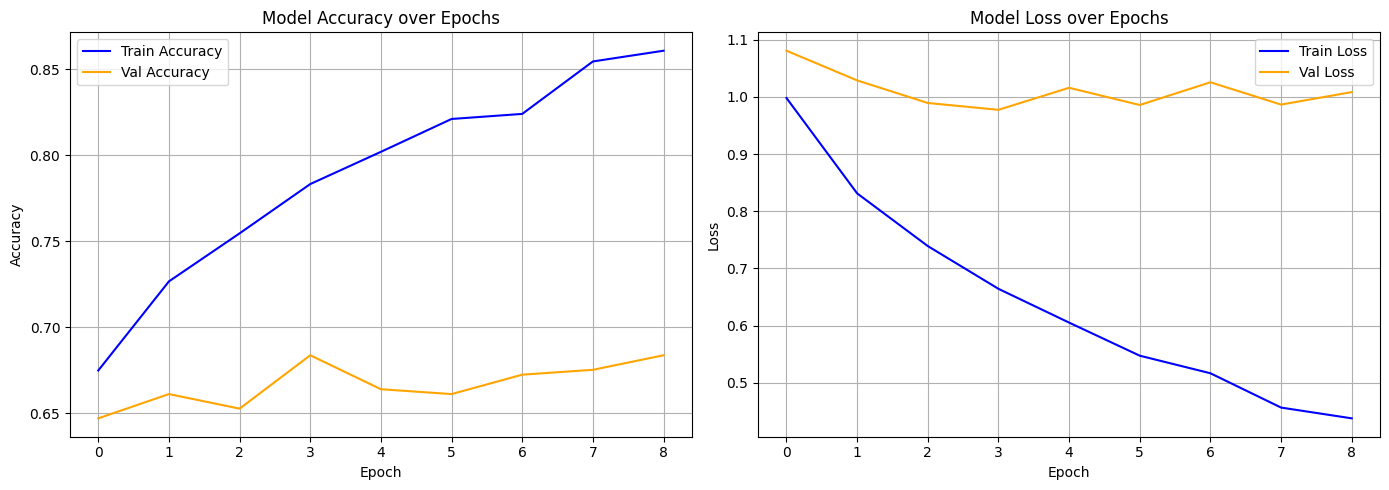

Training curves saved: /content/drive/MyDrive/FYP/fyp-model/training_curves.png


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint(
        f'{MODEL_SAVE_PATH}/baseline_best.keras',
        save_best_only=True, verbose=1
    )
]

print("Training baseline model...")
history = model.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(val_images, val_labels),
    callbacks=callbacks
)

_, baseline_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"\nBaseline test accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")

# Save to Drive
baseline_keras_path = f'{MODEL_SAVE_PATH}/baseline_model.keras'
model.save(baseline_keras_path)
print(f"Saved baseline model: {baseline_keras_path}")

# ── Plot training curves ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
curve_path = f'{MODEL_SAVE_PATH}/training_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Training curves saved: {curve_path}")

In [ ]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

batch_size     = BATCH
pruning_epochs = 10
validation_split = 0.1

num_images = train_images.shape[0] * (1 - validation_split)
end_step   = np.ceil(num_images / batch_size).astype(np.int32) * pruning_epochs

# FIXED: Much gentler pruning schedule
# Previous run: 20%->60% still caused collapse
# Now: 10%->50% with longer warmup
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.10,   # Start very light
        final_sparsity=0.50,     # End at 50% — balanced compression vs accuracy
        begin_step=end_step//4,  # Wait 25% of training before starting pruning
        end_step=end_step
    )
}

# FIXED: Only prune the Dense layers, NOT the base MobileNetV2
# Pruning MobileNetV2 weights is what caused the collapse
model_for_pruning = keras.Sequential([
    model.layers[0],   # MobileNetV2 base — NOT pruned
    keras.layers.GlobalAveragePooling2D(),
    prune_low_magnitude(
        keras.layers.Dense(128, activation='relu'),
        **pruning_params
    ),
    keras.layers.Dropout(0.3),
    prune_low_magnitude(
        keras.layers.Dense(NC),
        **pruning_params
    )
])

model_for_pruning.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_for_pruning.summary()
print("\nNote: Only Dense layers are pruned. MobileNetV2 base is kept intact.")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_0.35_224 (Func  (None, 7, 7, 1280)        410208    
 tional)                                                         
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 prune_low_magnitude_dense_  (None, 128)               327810    
 2 (PruneLowMagnitude)                                           
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 prune_low_magnitude_dense_  (None, 21)                5399      
 3 (PruneLowMagnitude)                                

In [ ]:
logdir = tempfile.mkdtemp()

callbacks_pruning = [
    tfmot.sparsity.keras.UpdatePruningStep(),
    tfmot.sparsity.keras.PruningSummaries(log_dir=logdir),
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

print("Training pruned model...")
pruning_history = model_for_pruning.fit(
    train_images, train_labels,
    batch_size=batch_size,
    epochs=pruning_epochs,
    validation_data=(val_images, val_labels),
    callbacks=callbacks_pruning
)

_, pruned_accuracy = model_for_pruning.evaluate(test_images, test_labels, verbose=0)
print(f"\nBaseline accuracy : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"Pruned accuracy   : {pruned_accuracy:.4f} ({pruned_accuracy*100:.1f}%)")
print(f"Accuracy drop     : {baseline_accuracy - pruned_accuracy:.4f}")
print(f"Accuracy retained : {pruned_accuracy/baseline_accuracy*100:.1f}%")

Training pruned model...
Epoch 1/10
170/170 [==============================] - 58s 310ms/step - loss: 2.1956 - accuracy: 0.3653 - val_loss: 2.0113 - val_accuracy: 0.4068 - lr: 1.0000e-04
Epoch 2/10
170/170 [==============================] - 49s 286ms/step - loss: 1.6119 - accuracy: 0.5195 - val_loss: 1.6045 - val_accuracy: 0.5395 - lr: 1.0000e-04
Epoch 3/10
170/170 [==============================] - 49s 288ms/step - loss: 1.3680 - accuracy: 0.5831 - val_loss: 1.4017 - val_accuracy: 0.5989 - lr: 1.0000e-04
Epoch 4/10
170/170 [==============================] - 49s 289ms/step - loss: 1.2168 - accuracy: 0.6273 - val_loss: 1.2909 - val_accuracy: 0.6328 - lr: 1.0000e-04
Epoch 5/10
170/170 [==============================] - 49s 287ms/step - loss: 1.1220 - accuracy: 0.6505 - val_loss: 1.2042 - val_accuracy: 0.6497 - lr: 1.0000e-04
Epoch 6/10
170/170 [==============================] - 53s 313ms/step - loss: 1.0556 - accuracy: 0.6821 - val_loss: 1.1463 - val_accuracy: 0.6384 - lr: 1.0000e-04
Epo

In [ ]:
model_for_export = tfmot.sparsity.keras.strip_pruning(model_for_pruning)

pruned_keras_path = f'{MODEL_SAVE_PATH}/pruned_model.keras'
model_for_export.save(pruned_keras_path)
print(f"Saved pruned model: {pruned_keras_path}")

converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
pruned_tflite_model = converter.convert()

pruned_tflite_path = f'{MODEL_SAVE_PATH}/pruned_model.tflite'
with open(pruned_tflite_path, 'wb') as f:
    f.write(pruned_tflite_model)
print(f"Saved pruned TFLite: {pruned_tflite_path}")

Saved pruned model: /content/drive/MyDrive/FYP/fyp-model/pruned_model.keras
Saved pruned TFLite: /content/drive/MyDrive/FYP/fyp-model/pruned_model.tflite


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_for_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
quantized_and_pruned_tflite_model = converter.convert()

final_tflite_path = f'{MODEL_SAVE_PATH}/fyp_navigation_model.tflite'
with open(final_tflite_path, 'wb') as f:
    f.write(quantized_and_pruned_tflite_model)
print(f"Saved final TFLite model: {final_tflite_path}")

Saved final TFLite model: /content/drive/MyDrive/FYP/fyp-model/fyp_navigation_model.tflite


In [ ]:
def get_gzipped_model_size(file_path):
    _, zipped_file = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(file_path)
    return os.path.getsize(zipped_file)


print("=" * 55)
print("MODEL SIZE COMPARISON")
print("=" * 55)
print(f"Baseline Keras     : {get_gzipped_model_size(baseline_keras_path)/1024:,.0f} KB")
print(f"Pruned Keras       : {get_gzipped_model_size(pruned_keras_path)/1024:,.0f} KB")
print(f"Pruned TFLite      : {get_gzipped_model_size(pruned_tflite_path)/1024:,.0f} KB")
print(f"Quantized+Pruned   : {get_gzipped_model_size(final_tflite_path)/1024:,.0f} KB  <-- deploy this")
print(f"\nActual file on disk: {os.path.getsize(final_tflite_path)/1024:.1f} KB")
print("=" * 55)

MODEL SIZE COMPARISON
Baseline Keras     : 3,078 KB
Pruned Keras       : 1,635 KB
Pruned TFLite      : 1,535 KB
Quantized+Pruned   : 497 KB  <-- deploy this

Actual file on disk: 692.0 KB


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

NAVIGATION_CLASSES = {
    0: 'person',       1: 'bicycle',      2: 'car',
    3: 'motorcycle',   4: 'bus',          5: 'truck',
    6: 'traffic light',7: 'stop sign',    8: 'bench',
    9: 'chair',        10: 'couch',       11: 'table',
    12: 'door',        13: 'window',      14: 'cabinet',
    15: 'pole',        16: 'stairs',      17: 'dog',
    18: 'cat',         19: 'fire hydrant',20: 'object'
}

# Colors for each zone
ZONE_COLORS = {
    'DANGER':  '#FF0000',
    'WARNING': '#FF8C00',
    'CAUTION': '#FFD700',
    'INFO':    '#00FF00',
    'OK':      '#00BFFF'
}

def estimate_distance(bw, bh):
    area = bw * bh
    if area > 0.35:   return "< 1m",   "DANGER"
    elif area > 0.15: return "1-2m",   "WARNING"
    elif area > 0.05: return "2-4m",   "CAUTION"
    elif area > 0.01: return "4-7m",   "INFO"
    else:             return "> 7m",   "OK"


def get_position(cx):
    if cx < 0.35:   return "left"
    elif cx > 0.65: return "right"
    else:           return "ahead"


def generate_audio_alert(detections):
    """Generate concise audio alert string"""
    if not detections:
        return "Path clear."

    # Sort by closest first
    detections = sorted(detections, key=lambda d: d['area'], reverse=True)

    parts = []
    for d in detections[:3]:
        parts.append(
            f"{d['name']} {d['dist']} {d['pos']}"
        )

    return " | ".join(parts)


def visualise_all_objects(model, img_dir, label_dir, n=6):
    """
    Show all annotated objects per image with:
    - Bounding boxes colour-coded by distance zone
    - All object labels shown
    - Distance and position for each object
    - Audio alert message
    - Model's top prediction shown separately
    """
    img_files = list(Path(img_dir).glob('*.jpg'))
    random.shuffle(img_files)
    img_files = img_files[:n]

    rows = (n + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(20, 7 * rows))
    axes = axes.flatten()

    for i, img_path in enumerate(img_files):
        if i >= n:
            break

        # Load original image
        orig = cv2.imread(str(img_path))
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        h, w = orig.shape[:2]

        # Model prediction
        img_resized = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
        img_input   = np.expand_dims(img_resized / 255.0, 0).astype(np.float32)
        preds       = model.predict(img_input, verbose=0)
        pred_cls    = int(np.argmax(preds[0]))
        confidence  = float(np.max(tf.nn.softmax(preds[0])))
        pred_name   = NAVIGATION_CLASSES.get(pred_cls, 'unknown')

        # Load ALL bounding boxes from label file
        label_path = Path(label_dir) / (img_path.stem + '.txt')
        detections = []

        axes[i].imshow(orig)

        if label_path.exists():
            with open(label_path) as f:
                lines = [l.strip() for l in f if l.strip()]

            for line in lines:
                parts = line.split()
                if len(parts) != 5:
                    continue

                cls_id = int(parts[0])
                cx, cy = float(parts[1]), float(parts[2])
                bw, bh = float(parts[3]), float(parts[4])

                dist, zone = estimate_distance(bw, bh)
                pos        = get_position(cx)
                name       = NAVIGATION_CLASSES.get(cls_id, 'object')
                color      = ZONE_COLORS[zone]

                # Draw bounding box
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                bw_px = int(bw * w)
                bh_px = int(bh * h)

                rect = patches.Rectangle(
                    (x1, y1), bw_px, bh_px,
                    linewidth=2.5, edgecolor=color, facecolor='none'
                )
                axes[i].add_patch(rect)

                # Label: class name + distance
                label_text = f"{name} | {dist} | {pos}"
                axes[i].text(
                    x1 + 3, y1 + 14,
                    label_text,
                    color='white', fontsize=7, weight='bold',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor=color, alpha=0.85)
                )

                detections.append({
                    'name': name,
                    'dist': dist,
                    'pos':  pos,
                    'zone': zone,
                    'area': bw * bh
                })

        # Generate audio alert
        alert = generate_audio_alert(detections)
        obj_count = len(detections)

        # Title block
        title_lines = [
            f"Model says: '{pred_name}' ({confidence:.0%})",
            f"Objects found: {obj_count}",
            f"Audio: \"{alert}\"",
        ]
        axes[i].set_title(
            "\n".join(title_lines),
            fontsize=8, loc='left',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.75),
            color='white'
        )
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(len(img_files), len(axes)):
        axes[j].axis('off')

    # Legend
    legend_text = (
        "Distance zones:  "
        "RED < 1m  |  ORANGE 1-2m  |  GOLD 2-4m  |  GREEN 4-7m  |  BLUE > 7m"
    )
    fig.text(0.5, 0.01, legend_text,
             ha='center', fontsize=9, color='white',
             bbox=dict(facecolor='black', alpha=0.7))

    plt.suptitle(
        'Navigation Aid — Object Detection + Distance Estimation Output',
        fontsize=13, weight='bold', color='white',
        bbox=dict(facecolor='black', alpha=0.8)
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])

    out_path = f'{MODEL_SAVE_PATH}/sample_predictions.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
    plt.show()
    print(f"Saved: {out_path}")


# Load best model and visualise
best_model = tf.keras.models.load_model(
    f'{MODEL_SAVE_PATH}/baseline_best.keras'
)

print("Generating visualisations...")
visualise_all_objects(
    model     = best_model,
    img_dir   = f'{DATASET_PATH}/test/images',
    label_dir = f'{DATASET_PATH}/test/labels',
    n=6
)

In [ ]:
print("=" * 55)
print("FINAL MODEL TRAINING SUMMARY")
print("=" * 55)
print(f"\nDataset:")
print(f"  Train  : {len(train_images)} images")
print(f"  Val    : {len(val_images)} images")
print(f"  Test   : {len(test_images)} images")
print(f"  Classes: {NC} navigation classes")
print(f"\nAccuracy:")
print(f"  Baseline (before pruning) : {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"  After pruning             : {pruned_accuracy:.4f} ({pruned_accuracy*100:.1f}%)")
print(f"  Accuracy retained         : {pruned_accuracy/baseline_accuracy*100:.1f}%")
print(f"\nModel sizes (compressed):")
print(f"  Baseline Keras     : {get_gzipped_model_size(baseline_keras_path)/1024:,.0f} KB")
print(f"  Pruned Keras       : {get_gzipped_model_size(pruned_keras_path)/1024:,.0f} KB")
print(f"  Pruned TFLite      : {get_gzipped_model_size(pruned_tflite_path)/1024:,.0f} KB")
print(f"  Quantized+Pruned   : {get_gzipped_model_size(final_tflite_path)/1024:,.0f} KB  <-- deploy this")
print(f"  Actual file size   : {os.path.getsize(final_tflite_path)/1024:.1f} KB")
print(f"\nFiles saved to Drive ({MODEL_SAVE_PATH}):")
print(f"  baseline_model.keras")
print(f"  baseline_best.keras")
print(f"  pruned_model.keras")
print(f"  pruned_model.tflite")
print(f"  fyp_navigation_model.tflite  <-- final deploy model")
print(f"  training_curves.png")
print(f"  sample_predictions.png")
print("=" * 55)

FINAL MODEL TRAINING SUMMARY

Dataset:
  Train  : 2718 images
  Val    : 354 images
  Test   : 238 images
  Classes: 21 navigation classes

Accuracy:
  Baseline (before pruning) : 0.5924 (59.2%)
  After pruning             : 0.5504 (55.0%)
  Accuracy retained         : 92.9%

Model sizes (compressed):
  Baseline Keras     : 3,078 KB
  Pruned Keras       : 1,635 KB
  Pruned TFLite      : 1,535 KB
  Quantized+Pruned   : 497 KB  <-- deploy this
  Actual file size   : 692.0 KB

Files saved to Drive (/content/drive/MyDrive/FYP/fyp-model):
  baseline_model.keras
  baseline_best.keras
  pruned_model.keras
  pruned_model.tflite
  fyp_navigation_model.tflite  <-- final deploy model
  training_curves.png
  sample_predictions.png
